# THỰC HÀNH TRÍ TUỆ NHÂN TẠO - BUỔI 5: HỌC MÁY
**Sinh viên thực hiện:** [Tên của bạn]
**Mục tiêu:** Cài đặt thuật toán K-Means, K-NN và các ứng dụng thực tế.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

# Cấu hình kích thước biểu đồ mặc định cho đẹp
plt.rcParams['figure.figsize'] = (8, 5)

## PHẦN III: BÀI TẬP TẠI LỚP
Khởi tạo dữ liệu giả lập cho không gian 2 chiều để test thuật toán.

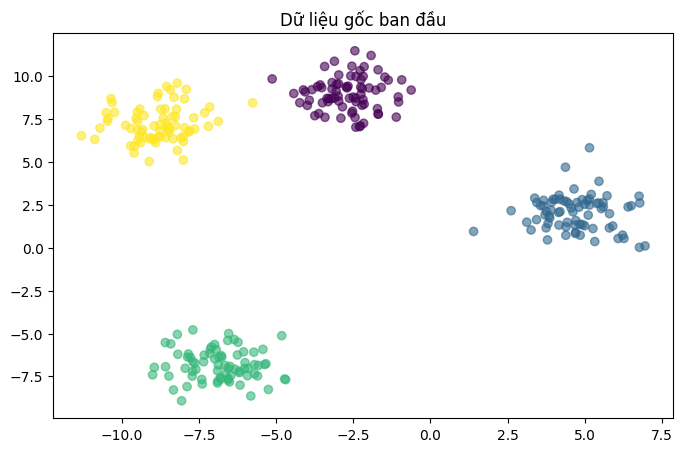

In [2]:
# Khởi tạo dữ liệu với 300 mẫu, chia thành 4 cụm
n_samples = 300
random_state = 42

X, y = make_blobs(
    n_samples=n_samples,
    centers=4,
    cluster_std=1.0,
    random_state=random_state
)

# Trực quan hóa dữ liệu gốc
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', alpha=0.6)
plt.title("Dữ liệu gốc ban đầu")
plt.show()

--- THỰC THI K-MEANS ---


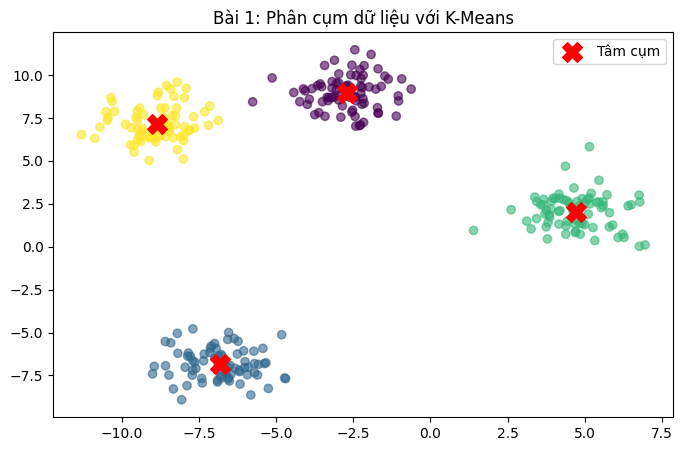

In [3]:
print("--- THỰC THI K-MEANS ---")
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
predicted_labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# Trực quan hóa kết quả phân cụm
plt.scatter(X[:, 0], X[:, 1], c=predicted_labels, cmap='viridis', marker='o', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Tâm cụm')
plt.title('Bài 1: Phân cụm dữ liệu với K-Means')
plt.legend()
plt.show()

In [4]:
print("--- THỰC THI K-NN ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=random_state
)

# Cách 1: Đánh giá với K cố định (k=5)
knn_fixed = KNeighborsClassifier(n_neighbors=5)
knn_fixed.fit(X_train, y_train)
y_pred = knn_fixed.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"[Cách 1] Độ chính xác với K=5: {accuracy * 100:.2f}%")

# Cách 2: Tìm K tối ưu tự động bằng GridSearchCV
param_grid = {'n_neighbors': np.arange(1, 15)}
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_grid.fit(X, y)

print(f"[Cách 2] K tối ưu tìm được: {knn_grid.best_params_['n_neighbors']}")
print(f"-> Độ chính xác kiểm chéo tốt nhất: {knn_grid.best_score_ * 100:.2f}%")

--- THỰC THI K-NN ---
[Cách 1] Độ chính xác với K=5: 98.67%
[Cách 2] K tối ưu tìm được: 1
-> Độ chính xác kiểm chéo tốt nhất: 100.00%


## PHẦN IV: BÀI TẬP VỀ NHÀ
Mô tả và cài đặt demo các ứng dụng thực tế.

In [5]:
print("--- ỨNG DỤNG K-MEANS: PHÂN CỤM KHÁCH HÀNG ---")
# Dữ liệu: [Tuổi, Điểm chi tiêu (1-100)]
data = {
    'Age': [25, 22, 28, 65, 60, 58, 30, 29],
    'SpendingScore': [85, 90, 80, 15, 20, 10, 88, 75]
}
df_customers = pd.DataFrame(data)

# Phân thành 2 nhóm: Khách hàng trẻ/Tiêu nhiều và Khách hàng lớn tuổi/Tiêu ít
kmeans_app = KMeans(n_clusters=2, random_state=0, n_init='auto')
df_customers['Segment'] = kmeans_app.fit_predict(df_customers)

print(df_customers.to_string(index=False))

--- ỨNG DỤNG K-MEANS: PHÂN CỤM KHÁCH HÀNG ---
 Age  SpendingScore  Segment
  25             85        1
  22             90        1
  28             80        1
  65             15        0
  60             20        0
  58             10        0
  30             88        1
  29             75        1


In [6]:
print("--- ỨNG DỤNG K-NN: CHẨN ĐOÁN Y KHOA ---")
# Dữ liệu: [Huyết áp, Lượng đường] -> Nhãn: 0 (Khỏe), 1 (Bệnh)
X_medical = np.array([[120, 80], [130, 85], [140, 100], [150, 110], [115, 75], [160, 120]])
y_medical = np.array([0, 0, 1, 1, 0, 1])

knn_app = KNeighborsClassifier(n_neighbors=3)
knn_app.fit(X_medical, y_medical)

# Dự đoán cho bệnh nhân mới
new_patient = np.array([[145, 105]])
prediction = knn_app.predict(new_patient)

status = "CÓ NGUY CƠ BỆNH" if prediction[0] == 1 else "KHỎE MẠNH"
print(f"Chỉ số bệnh nhân mới: {new_patient[0]} -> Chuẩn đoán: {status}")

--- ỨNG DỤNG K-NN: CHẨN ĐOÁN Y KHOA ---
Chỉ số bệnh nhân mới: [145 105] -> Chuẩn đoán: CÓ NGUY CƠ BỆNH


In [7]:
print("--- ỨNG DỤNG DECISION TREE: PHÊ DUYỆT KHOẢN VAY ---")
# Dữ liệu: [Thu nhập (Triệu), Nợ xấu (0=Không, 1=Có)] -> Nhãn: 1 (Duyệt), 0 (Từ chối)
X_loan = np.array([[20, 0], [10, 0], [30, 1], [5, 1], [50, 0], [12, 0]])
y_loan = np.array([1, 1, 0, 0, 1, 0])

tree_model = DecisionTreeClassifier(random_state=0)
tree_model.fit(X_loan, y_loan)

# Khách hàng nộp hồ sơ mới: Thu nhập 25 triệu, Không có nợ xấu
new_applicant = np.array([[25, 0]])
pred_loan = tree_model.predict(new_applicant)

loan_status = "ĐÃ PHÊ DUYỆT" if pred_loan[0] == 1 else "BỊ TỪ CHỐI"
print(f"Hồ sơ [Thu nhập 25tr, Nợ xấu: 0] -> Trạng thái: {loan_status}")

--- ỨNG DỤNG DECISION TREE: PHÊ DUYỆT KHOẢN VAY ---
Hồ sơ [Thu nhập 25tr, Nợ xấu: 0] -> Trạng thái: ĐÃ PHÊ DUYỆT
